# Wave Equation with NumPy

## Authors:

Zach Etienne, Patrick Nelson, Terrence Pierre Jacques, Thiago Assumpção,
Leo Werneck, and Brandon Clark.

This notebook adapts the legacy NRPy scalar-wave NumPy tutorial. Zach wrote
the NRPy infrastructure and notebook code; Patrick, Terrence, and Thiago
contributed the wave-equation infrastructure history; Leo created the
boundary-condition animation; Brandon established the notebook formatting
standards used by the legacy tutorial.

To run the whole notebook, click the `>>` toolbar button and choose
**Restart Kernel and Run All Cells...**.

This notebook evolves the scalar wave equation directly with NumPy, applies
quadratic-extrapolation ghost-zone boundary conditions, and validates the
result against recorded fourth-order convergence data from the legacy
tutorial.

**Notebook Status:** Validated

**Validation Notes:** The final validation section compares pointwise
center-error diagnostics across the `24^3`, `48^3`, and `96^3` grid family
and checks fourth-order convergence.

Navigation: [Index](../index.ipynb) |
Previous: [Reference Metric](../1-intro/reference_metric.ipynb) |
Next: [Method of Lines and Runge-Kutta](method_of_lines_and_rk.ipynb)

# Table of Contents

1. [Required Reading and Source Links](#Required-Reading-and-Source-Links)
1. [Words for This Notebook](#Words-for-This-Notebook)
1. [Step 1](#Step-1:-State-the-Scalar-Wave-Initial-Value-Problem):
   State the initial-value problem.
1. [Step 2](#Step-2:-Build-the-Cartesian-Grid-and-Flattened-Storage): Build the grid.
1. [Step 3](#Step-3:-Set-Spherical-Gaussian-Initial-Data): Set initial data.
1. [Step 4](#Step-4:-Evaluate-the-Fourth-Order-Interior-Right-Hand-Side): Evaluate the RHS.
1. [Step 5](#Step-5:-Fill-Ghost-Zones-by-Quadratic-Extrapolation): Fill ghost zones.
1. [Step 6](#Step-6:-Advance-One-RK4-Step-with-Boundary-Updates): Advance one RK4 step.
1. [Step 7](#Step-7:-Run-the-Live-24-Cubed-Evolution): Run the live grid.
1. [Step 8](#Step-8:-Compare-the-Recorded-Grid-Family): Compare grid family data.
1. [Validation Check](#Validation-Check): Validate convergence.
1. [What next?](#What-next?)

# Required Reading and Source Links
### [Back to [top](#Table-of-Contents)]

This notebook's numerical code is self-contained except for basic Python and
NumPy. The recorded data and boundary animation are inherited from the legacy
NRPy scalar-wave tutorial lineage.

Sources used by the lesson:

- `bdrycond_general_algorithm.gif`: local copy of the legacy boundary
  animation used below.
- `nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData`:
  pip-installed source module for NRPy's analytic wave initial data.

This source-provenance check must resolve NRPy through the pip-installed
package. It raises immediately if a local cloned `nrpy/` directory shadows the
installed package.

In [1]:
from pathlib import Path
import importlib.util
import logging


NOTEBOOK_DIR = Path.cwd().resolve()
FORBIDDEN_SOURCE_ROOTS = [NOTEBOOK_DIR.parent / "nrpy"]
logging.getLogger("matplotlib").setLevel(logging.WARNING)


def installed_source_path(module_name):
    spec = importlib.util.find_spec(module_name)
    if spec is None or spec.origin is None:
        raise RuntimeError(f"Could not locate installed module: {module_name}")
    path = Path(spec.origin).resolve()
    for root in FORBIDDEN_SOURCE_ROOTS:
        if not root.exists():
            continue
        try:
            path.relative_to(root.resolve())
        except ValueError:
            continue
        raise RuntimeError(f"{module_name} resolved to cloned source: {path}")
    return path


source_module = "nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData"
print("installed NRPy source path:")
print(source_module, "->", installed_source_path(source_module))

installed NRPy source path:
nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData -> /virt/lib/python3.12/site-packages/nrpy/equations/wave_equation/WaveEquation_Solutions_InitialData.py


# Words for This Notebook
### [Back to [top](#Table-of-Contents)]

- **`u`:** The scalar wave amplitude evolved on the grid.
- **`v`:** The auxiliary field `partial_t u`; it makes the wave equation
  first order in time.
- **Wave speed:** The constant `c` in `partial_t^2 u = c^2 nabla^2 u`.
- **Initial data:** Values of `u` and `v` at `t = 0`.
- **Method of Lines:** First discretize space, then integrate the remaining
  time ordinary differential equation. See the
  [source](https://reference.wolfram.com/language/tutorial/NDSolveMethodOfLines.html).
- **RK4:** The classical four-stage Runge-Kutta method used to advance the
  Method-of-Lines state. See the
  [Runge-Kutta methods overview](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods).
- **Fourth-order finite-difference stencil:** A weighted sum whose leading
  spatial truncation error scales like `Delta x^4`.
- **Boundary condition:** A rule for values at the grid boundary; here we fill
  ghost zones by quadratic extrapolation.
- **Ghost zone:** Extra grid cells outside the physical domain that allow
  centered stencils near a boundary to read neighboring values.
- **Pointwise relative error:** `abs((u_numeric - u_exact) / u_exact)` at one
  diagnostic point; it is a pointwise diagnostic, not a norm.

# Step 1: State the Scalar Wave Initial-Value Problem
### [Back to [top](#Table-of-Contents)]

The Cartesian scalar wave equation is

$$
\partial_t^2 u = c^2 \nabla^2 u .
$$

We evolve it on a cell-centered Cartesian cube
`[-domain_size, domain_size]^3` with dimensionless tutorial units and
`c = 1`. Introducing

$$
v = \partial_t u
$$

gives the first-order-in-time system

$$
\partial_t u = v,\qquad
\partial_t v = c^2 \nabla^2 u .
$$

The exact solution used for initial data is an ingoing-plus-outgoing
spherical Gaussian. With

$$
r = \sqrt{x^2 + y^2 + z^2},
$$

the wave amplitude is

$$
u(t,r) =
\frac{(r - ct)e^{-(r - ct)^2/(2\sigma^2)}}{r}
+ \frac{(r + ct)e^{-(r + ct)^2/(2\sigma^2)}}{r}
+ u_{\rm offset}.
$$

The code below evaluates the analytic time derivative `v = partial_t u`.
The positive offset keeps the denominator in the pointwise relative error
away from zero. The cell-centered grid avoids sampling `r = 0`, so the
displayed formula is finite at every grid point used here.

Boundary conditions fill two ghost zones on every outer face. The Method of
Lines advances the flattened state arrays with RK4. The expected behavior is
fourth-order spatial convergence for this smooth short-time run.

# Step 2: Build the Cartesian Grid and Flattened Storage
### [Back to [top](#Table-of-Contents)]

The live run uses the same `24^3` interior grid as the legacy NumPy example.
Larger `48^3` and `96^3` data are used later from the recorded legacy table
because pure-Python loops at those resolutions are too slow for an
interactive tutorial.

Inspect the printed grid size, spacing, time step, and final time.

In [2]:
import numpy as np

domain_size = 1.0
freeparam_c = 1.0
freeparam_sigma = 3.0
freeparam_u_offset = 1.0

Nx = Ny = Nz = 24
NGHOSTS = 2

xmin = ymin = zmin = -domain_size
xmax = ymax = zmax = +domain_size

dx = (xmax - xmin) / Nx
dy = (ymax - ymin) / Ny
dz = (zmax - zmin) / Nz

xx = np.zeros(Nx + 2 * NGHOSTS)
yy = np.zeros(Ny + 2 * NGHOSTS)
zz = np.zeros(Nz + 2 * NGHOSTS)

for i in range(Nx + 2 * NGHOSTS):
    xx[i] = xmin + (i - NGHOSTS + 0.5) * dx
for j in range(Ny + 2 * NGHOSTS):
    yy[j] = ymin + (j - NGHOSTS + 0.5) * dy
for k in range(Nz + 2 * NGHOSTS):
    zz[k] = zmin + (k - NGHOSTS + 0.5) * dz

dt = 0.5 * min(dx, dy, dz) / freeparam_c
t_final = 0.5 * domain_size

grid_size = (Nx + 2 * NGHOSTS) * (Ny + 2 * NGHOSTS) * (Nz + 2 * NGHOSTS)
center_i = (Nx + 2 * NGHOSTS) // 2
center_j = (Ny + 2 * NGHOSTS) // 2
center_k = (Nz + 2 * NGHOSTS) // 2

print("grid:", f"{Nx}^3 interior points plus {NGHOSTS} ghost zones")
print("dx:", f"{dx:.6e}", "dt:", f"{dt:.6e}", "t_final:", f"{t_final:.6e}")
print("center coordinates:", f"({xx[center_i]:.6f}, {yy[center_j]:.6f}, {zz[center_k]:.6f})")

grid: 24^3 interior points plus 2 ghost zones
dx: 8.333333e-02 dt: 4.166667e-02 t_final: 5.000000e-01
center coordinates: (0.041667, 0.041667, 0.041667)


The grid is cell-centered, so the point nearest the origin has nonzero
radius. That is why the spherical exact solution can be evaluated without a
special `r = 0` branch in this notebook.

# Step 3: Set Spherical-Gaussian Initial Data
### [Back to [top](#Table-of-Contents)]

The next cell defines the exact wave amplitude `u` and its analytic time
derivative `v`, allocates flattened grid arrays, and fills them at `t = 0`.
The `IDX3D()` function is the same memory-layout idea later used by generated
C code.

In [3]:
def IDX3D(i, j, k):
    return i + (Nx + 2 * NGHOSTS) * (j + (Ny + 2 * NGHOSTS) * k)


u = np.zeros(grid_size)
v = np.zeros(grid_size)
u_k1 = np.zeros(grid_size)
v_k1 = np.zeros(grid_size)
u_k2 = np.zeros(grid_size)
v_k2 = np.zeros(grid_size)
u_k3 = np.zeros(grid_size)
v_k3 = np.zeros(grid_size)
u_k4 = np.zeros(grid_size)
v_k4 = np.zeros(grid_size)
u_tmp = np.zeros(grid_size)
v_tmp = np.zeros(grid_size)


def exact_solution_single_pt_u(time, x_i, y_j, z_k):
    r = np.sqrt(x_i * x_i + y_j * y_j + z_k * z_k)
    outgoing = (r - freeparam_c * time) * np.exp(
        -((r - freeparam_c * time) ** 2) / (2.0 * freeparam_sigma**2)
    ) / r
    ingoing = (r + freeparam_c * time) * np.exp(
        -((r + freeparam_c * time) ** 2) / (2.0 * freeparam_sigma**2)
    ) / r
    return outgoing + ingoing + freeparam_u_offset


def exact_solution_single_pt_v(time, x_i, y_j, z_k):
    r = np.sqrt(x_i * x_i + y_j * y_j + z_k * z_k)
    c = freeparam_c
    sigma = freeparam_sigma
    return (
        c * np.exp(-((c * time + r) ** 2) / (2.0 * sigma**2)) / r
        - c * np.exp(-((-c * time + r) ** 2) / (2.0 * sigma**2)) / r
        + c
        * (-c * time + r) ** 2
        * np.exp(-((-c * time + r) ** 2) / (2.0 * sigma**2))
        / (sigma**2 * r)
        - c
        * (c * time + r) ** 2
        * np.exp(-((c * time + r) ** 2) / (2.0 * sigma**2))
        / (sigma**2 * r)
    )


def exact_solution_all_points(time, u_gf, v_gf):
    for k in range(Nz + 2 * NGHOSTS):
        for j in range(Ny + 2 * NGHOSTS):
            for i in range(Nx + 2 * NGHOSTS):
                idx = IDX3D(i, j, k)
                u_gf[idx] = exact_solution_single_pt_u(time, xx[i], yy[j], zz[k])
                v_gf[idx] = exact_solution_single_pt_v(time, xx[i], yy[j], zz[k])


exact_solution_all_points(0.0, u, v)
center_idx = IDX3D(center_i, center_j, center_k)
print("allocated gridfunction entries:", grid_size)
print("initial center u:", f"{u[center_idx]:.12f}")
print("initial center v:", f"{v[center_idx]:.12e}")

allocated gridfunction entries: 21952
initial center u: 2.999421380013
initial center v: 0.000000000000e+00


The initial `u` value is close to `3` because the Gaussian terms and the
offset both contribute near the origin. The `v` value is finite because the
center diagnostic point is not exactly at `r = 0`.

# Step 4: Evaluate the Fourth-Order Interior Right-Hand Side
### [Back to [top](#Table-of-Contents)]

The right-hand-side routine implements
`partial_t u = v` and `partial_t v = c^2 nabla^2 u` on interior points only.
Each second derivative uses the fourth-order centered stencil

$$
\partial_x^2 u_i \approx
\frac{-u_{i-2} + 16u_{i-1} - 30u_i + 16u_{i+1} - u_{i+2}}
{12 \Delta x^2}.
$$

Ghost zones are filled separately before boundary-adjacent stencil reads are
needed.

In [4]:
def eval_rhs_all_interior_points(u_gf, v_gf, u_rhs, v_rhs):
    for k in range(NGHOSTS, Nz + NGHOSTS):
        for j in range(NGHOSTS, Ny + NGHOSTS):
            for i in range(NGHOSTS, Nx + NGHOSTS):
                idx = IDX3D(i, j, k)
                u_rhs[idx] = v_gf[idx]
                d2u_dx2 = (
                    -1.0 / 12.0 * (u_gf[IDX3D(i - 2, j, k)] + u_gf[IDX3D(i + 2, j, k)])
                    + 4.0 / 3.0 * (u_gf[IDX3D(i - 1, j, k)] + u_gf[IDX3D(i + 1, j, k)])
                    - 5.0 / 2.0 * u_gf[idx]
                ) / (dx * dx)
                d2u_dy2 = (
                    -1.0 / 12.0 * (u_gf[IDX3D(i, j - 2, k)] + u_gf[IDX3D(i, j + 2, k)])
                    + 4.0 / 3.0 * (u_gf[IDX3D(i, j - 1, k)] + u_gf[IDX3D(i, j + 1, k)])
                    - 5.0 / 2.0 * u_gf[idx]
                ) / (dy * dy)
                d2u_dz2 = (
                    -1.0 / 12.0 * (u_gf[IDX3D(i, j, k - 2)] + u_gf[IDX3D(i, j, k + 2)])
                    + 4.0 / 3.0 * (u_gf[IDX3D(i, j, k - 1)] + u_gf[IDX3D(i, j, k + 1)])
                    - 5.0 / 2.0 * u_gf[idx]
                ) / (dz * dz)
                v_rhs[idx] = freeparam_c**2 * (d2u_dx2 + d2u_dy2 + d2u_dz2)


eval_rhs_all_interior_points(u, v, u_k1, v_k1)
print("sample u RHS at center:", f"{u_k1[center_idx]:.12e}")
print("sample v RHS at center:", f"{v_k1[center_idx]:.12e}")

sample u RHS at center: 0.000000000000e+00
sample v RHS at center: -6.663451636570e-01


The `u` right-hand side equals the current `v`. The `v` right-hand side is
the finite-difference Laplacian contribution at the same point.

# Step 5: Fill Ghost Zones by Quadratic Extrapolation
### [Back to [top](#Table-of-Contents)]

The image below is the local copy of the legacy NRPy boundary-condition
animation. It is the legacy NRPy boundary-condition animation used to show
the ghost-zone fill order.
It shows one ghost-zone layer being filled at a time. After each face update,
the active box expands so edge and corner values can use already-filled
neighboring ghost-zone data.

<img src="bdrycond_general_algorithm.gif" width="450" align="center">

For each face point, quadratic extrapolation fills

$$
u_{\rm ghost} = 3u_1 - 3u_2 + u_3,
$$

where `u_1`, `u_2`, and `u_3` are the next three points inward along the face
normal.

In [5]:
def bc_face_update(
    gf,
    i0min,
    i0max,
    i1min,
    i1max,
    i2min,
    i2max,
    FACEX0,
    FACEX1,
    FACEX2,
):
    for i2 in range(i2min, i2max):
        for i1 in range(i1min, i1max):
            for i0 in range(i0min, i0max):
                gf[IDX3D(i0, i1, i2)] = (
                    +3.0 * gf[IDX3D(i0 + FACEX0, i1 + FACEX1, i2 + FACEX2)]
                    - 3.0
                    * gf[IDX3D(i0 + 2 * FACEX0, i1 + 2 * FACEX1, i2 + 2 * FACEX2)]
                    + 1.0
                    * gf[IDX3D(i0 + 3 * FACEX0, i1 + 3 * FACEX1, i2 + 3 * FACEX2)]
                )


MAXFACE = -1
NUL = 0
MINFACE = +1


def apply_extrapolation_bcs(u_gf, v_gf):
    for gf in [u_gf, v_gf]:
        imin = [NGHOSTS, NGHOSTS, NGHOSTS]
        imax = [Nx + NGHOSTS, Ny + NGHOSTS, Nz + NGHOSTS]
        for _which_gz in range(NGHOSTS):
            bc_face_update(
                gf, imin[0] - 1, imin[0], imin[1], imax[1], imin[2], imax[2],
                MINFACE, NUL, NUL,
            )
            imin[0] -= 1
            bc_face_update(
                gf, imax[0], imax[0] + 1, imin[1], imax[1], imin[2], imax[2],
                MAXFACE, NUL, NUL,
            )
            imax[0] += 1
            bc_face_update(
                gf, imin[0], imax[0], imin[1] - 1, imin[1], imin[2], imax[2],
                NUL, MINFACE, NUL,
            )
            imin[1] -= 1
            bc_face_update(
                gf, imin[0], imax[0], imax[1], imax[1] + 1, imin[2], imax[2],
                NUL, MAXFACE, NUL,
            )
            imax[1] += 1
            bc_face_update(
                gf, imin[0], imax[0], imin[1], imax[1], imin[2] - 1, imin[2],
                NUL, NUL, MINFACE,
            )
            imin[2] -= 1
            bc_face_update(
                gf, imin[0], imax[0], imin[1], imax[1], imax[2], imax[2] + 1,
                NUL, NUL, MAXFACE,
            )
            imax[2] += 1


apply_extrapolation_bcs(u, v)
ghost_idx = IDX3D(NGHOSTS - 1, NGHOSTS, NGHOSTS)
print("lower-x ghost u sample:", f"{u[ghost_idx]:.12f}")
print("boundary layers filled:", NGHOSTS)

lower-x ghost u sample: 2.700294555429
boundary layers filled: 2


The sample ghost value is not exact-solution data; it is the extrapolated
value that lets centered interior stencil code read across the physical edge.

# Step 6: Advance One RK4 Step with Boundary Updates
### [Back to [top](#Table-of-Contents)]

RK4 needs four right-hand-side evaluations. The boundary update is applied to
each temporary RK state before the next RHS evaluation, then once more after
the final update.

In [6]:
def one_RK_step():
    eval_rhs_all_interior_points(u, v, u_k1, v_k1)

    for idx in range(grid_size):
        u_tmp[idx] = u[idx] + 0.5 * dt * u_k1[idx]
        v_tmp[idx] = v[idx] + 0.5 * dt * v_k1[idx]
    apply_extrapolation_bcs(u_tmp, v_tmp)

    eval_rhs_all_interior_points(u_tmp, v_tmp, u_k2, v_k2)

    for idx in range(grid_size):
        u_tmp[idx] = u[idx] + 0.5 * dt * u_k2[idx]
        v_tmp[idx] = v[idx] + 0.5 * dt * v_k2[idx]
    apply_extrapolation_bcs(u_tmp, v_tmp)

    eval_rhs_all_interior_points(u_tmp, v_tmp, u_k3, v_k3)

    for idx in range(grid_size):
        u_tmp[idx] = u[idx] + dt * u_k3[idx]
        v_tmp[idx] = v[idx] + dt * v_k3[idx]
    apply_extrapolation_bcs(u_tmp, v_tmp)

    eval_rhs_all_interior_points(u_tmp, v_tmp, u_k4, v_k4)

    for idx in range(grid_size):
        u[idx] += dt * (u_k1[idx] + 2.0 * u_k2[idx] + 2.0 * u_k3[idx] + u_k4[idx]) / 6.0
        v[idx] += dt * (v_k1[idx] + 2.0 * v_k2[idx] + 2.0 * v_k3[idx] + v_k4[idx]) / 6.0
    apply_extrapolation_bcs(u, v)


one_RK_step()
print("one-step center u:", f"{u[center_idx]:.12f}")
print("one-step time:", f"{dt:.6e}")

one-step center u: 2.998843001874
one-step time: 4.166667e-02


This one-step check proves the complete update path is callable: RHS,
temporary-state boundary fills, final RK4 combination, and final boundary
fill.

# Step 7: Run the Live 24-Cubed Evolution
### [Back to [top](#Table-of-Contents)]

The diagnostic table records time, `log10` pointwise relative error,
numerical `u`, and exact `u` at the grid point nearest the origin.

In [7]:
exact_solution_all_points(0.0, u, v)
apply_extrapolation_bcs(u, v)
print("diagnostic point:", f"({xx[center_i]:.2f}, {yy[center_j]:.2f}, {zz[center_k]:.2f})")


def diagnostics(n):
    curr_time = n * dt
    numerical = u[center_idx]
    exact = exact_solution_single_pt_u(curr_time, xx[center_i], yy[center_j], zz[center_k])
    rel_error = abs((numerical - exact) / exact)
    log10relerror = np.log10(max(1.0e-16, rel_error))
    return curr_time, log10relerror, numerical, exact


n_final = int(t_final / dt + 0.5)
n_out_every = max(1, int(Nx / 24.0))
run_rows = [diagnostics(0)]

for n in range(n_final):
    one_RK_step()
    if (n + 1) % n_out_every == 0:
        run_rows.append(diagnostics(n + 1))

print("time log10_pointwise_relative_error numerical exact")
for row in run_rows:
    print(f"{row[0]:.2f} {row[1]:.2f} {row[2]:.12f} {row[3]:.12f}")

diagnostic point: (0.04, 0.04, 0.04)


time log10_pointwise_relative_error numerical exact
0.00 -16.00 2.999421380013 2.999421380013
0.04 -10.70 2.998843001874 2.998843001814
0.08 -10.06 2.997108425138 2.997108424880
0.12 -9.70 2.994219322036 2.994219321440
0.17 -9.45 2.990178477110 2.990178476038
0.21 -9.25 2.984989783456 2.984989781772
0.25 -9.09 2.978658237475 2.978658235046
0.29 -8.95 2.971189932137 2.971189928832
0.33 -8.84 2.962592048775 2.962592044465
0.38 -8.73 2.952872847434 2.952872841973
0.42 -8.63 2.942041655798 2.942041648971
0.46 -8.54 2.930108856544 2.930108848127
0.50 -8.49 2.917085872643 2.917085863230


The first diagnostic row is at machine precision because the grid was reset
to the exact initial data. Later rows measure numerical evolution error at
the same point.

# Step 8: Compare the Recorded Grid Family
### [Back to [top](#Table-of-Contents)]

The legacy tutorial records the same pointwise diagnostic for `24^3`, `48^3`,
and `96^3` grids. We reuse those rows here so the notebook remains quick to
run while still validating the expected resolution trend.

The next cell prints the final `log10` error for each resolution. The
validation section converts those logs back to errors before measuring order.

In [8]:
legacy_results = {
    24: """
0.00 -16.00 2.999421380013 2.999421380013
0.04 -10.70 2.998843001874 2.998843001814
0.08 -10.06 2.997108425138 2.997108424880
0.12 -9.70 2.994219322036 2.994219321440
0.17 -9.45 2.990178477110 2.990178476038
0.21 -9.25 2.984989783456 2.984989781772
0.25 -9.09 2.978658237475 2.978658235046
0.29 -8.95 2.971189932138 2.971189928832
0.33 -8.84 2.962592048775 2.962592044465
0.38 -8.73 2.952872847425 2.952872841973
0.42 -8.64 2.942041655765 2.942041648971
0.46 -8.54 2.930108856521 2.930108848127
0.50 -8.48 2.917085872939 2.917085863230
""",
    48: """
0.00 -16.00 2.999855329307 2.999855329307
0.04 -11.87 2.999276741878 2.999276741874
0.08 -11.25 2.997541537534 2.997541537518
0.12 -10.89 2.994651389354 2.994651389316
0.17 -10.64 2.990609083291 2.990609083222
0.21 -10.45 2.985418514411 2.985418514305
0.25 -10.29 2.979084681648 2.979084681494
0.29 -10.15 2.971613681053 2.971613680844
0.33 -10.04 2.963012697588 2.963012697316
0.38 -9.93 2.953289995451 2.953289995108
0.42 -9.84 2.942454906957 2.942454906535
0.46 -9.76 2.930517820003 2.930517819496
0.50 -9.69 2.917490164124 2.917490163524
""",
    96: """
0.00 -16.00 2.999963831346 2.999963831346
0.04 -13.06 2.999385191594 2.999385191594
0.08 -12.45 2.997649830354 2.997649830353
0.12 -12.09 2.994759420914 2.994759420911
0.17 -11.84 2.990716749579 2.990716749575
0.21 -11.65 2.985525711912 2.985525711906
0.25 -11.49 2.979191307475 2.979191307466
0.29 -11.36 2.971719633092 2.971719633079
0.33 -11.24 2.963117874631 2.963117874614
0.38 -11.14 2.953394297333 2.953394297311
0.42 -11.05 2.942558234689 2.942558234663
0.46 -10.97 2.930620075904 2.930620075872
0.50 -10.89 2.917591251949 2.917591251911
""",
}

parsed_results = {}
for resolution, text in legacy_results.items():
    parsed_results[resolution] = np.loadtxt(text.splitlines())

print("resolution final_log10_pointwise_relative_error")
for resolution in [24, 48, 96]:
    print(resolution, f"{parsed_results[resolution][-1, 1]:.2f}")

resolution final_log10_pointwise_relative_error
24 -8.48
48 -9.69
96 -10.89


The convergence plot shifts the log errors by the fourth-order expectation.
If the errors converge as `Delta x^4`, the shifted curves should overlap.

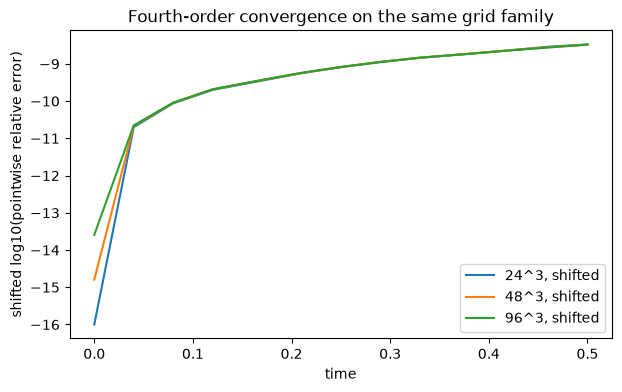

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
for resolution, color in [(24, "tab:blue"), (48, "tab:orange"), (96, "tab:green")]:
    data = parsed_results[resolution]
    shifted_log_error = data[:, 1] + 4.0 * np.log10(resolution / 24.0)
    plt.plot(data[:, 0], shifted_log_error, color=color, label=f"{resolution}^3, shifted")

plt.xlabel("time")
plt.ylabel("shifted log10(pointwise relative error)")
plt.title("Fourth-order convergence on the same grid family")
plt.legend()
plt.show()

# Validation Check
### [Back to [top](#Table-of-Contents)]

This validation uses the legacy `log10` pointwise relative errors as the
trusted comparison data. The newly computed check converts those logs to
errors, measures order between adjacent resolution doublings, and requires
both measured orders to be within `0.25` of the fourth-order expectation.

In [10]:
expected_order = 4.0
order_tolerance = 0.25
final_log_errors = {
    resolution: parsed_results[resolution][-1, 1]
    for resolution in [24, 48, 96]
}
final_errors = {
    resolution: 10.0 ** final_log_errors[resolution]
    for resolution in [24, 48, 96]
}
measured_order_24_48 = np.log(final_errors[24] / final_errors[48]) / np.log(2.0)
measured_order_48_96 = np.log(final_errors[48] / final_errors[96]) / np.log(2.0)

print("diagnostic type: pointwise center relative error in u")
print("norm type: pointwise diagnostic, not a norm")
print("expected order:", f"{expected_order:.1f}")
print("order tolerance:", f"{order_tolerance:.2f}")
print("resolution final_log10_error final_error")
for resolution in [24, 48, 96]:
    print(
        resolution,
        f"{final_log_errors[resolution]:.2f}",
        f"{final_errors[resolution]:.6e}",
    )
print("measured order 24 to 48:", f"{measured_order_24_48:.3f}")
print("measured order 48 to 96:", f"{measured_order_48_96:.3f}")
if abs(measured_order_24_48 - expected_order) > order_tolerance:
    raise RuntimeError("Measured order from 24^3 to 48^3 is outside tolerance.")
if abs(measured_order_48_96 - expected_order) > order_tolerance:
    raise RuntimeError("Measured order from 48^3 to 96^3 is outside tolerance.")
print("PASS: recorded grid family shows fourth-order convergence")

diagnostic type: pointwise center relative error in u
norm type: pointwise diagnostic, not a norm
expected order: 4.0
order tolerance: 0.25
resolution final_log10_error final_error
24 -8.48 3.311311e-09
48 -9.69 2.041738e-10
96 -10.89 1.288250e-11
measured order 24 to 48: 4.020
measured order 48 to 96: 3.986
PASS: recorded grid family shows fourth-order convergence


The validation uses pointwise center diagnostics rather than a grid norm. The
fourth-order result is the numerical evidence that the direct NumPy algorithm
matches the expected smooth-solution convergence trend.

# What next?
### [Back to [top](#Table-of-Contents)]

- [Method of Lines and Runge-Kutta](method_of_lines_and_rk.ipynb)
- [Boundary Conditions and Convergence](boundary_conditions_and_convergence.ipynb)
- [Wave Equation and C Code Generation](../3-wave_equation/wave_equation_and_c_codegen.ipynb)